# Tomato Maturity Detection

### Dataset: Tomato Maturity Detection and Quality Grading - kaggle
link: https://www.kaggle.com/datasets/sujaykapadnis/tomato-maturity-detection-and-quality-grading
Image Classification 

# Import Libraries

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import keras as k
import pandas as pd
from tqdm import tqdm
import cv2

# Read Dataset

In [35]:
# Specify the path to the directory containing your images (Read Dataset)
data_dir = 'D:/Tomato_Detection/Augment Dataset/'


# Pre-processing

# Image Size

In [36]:
# Define img_height, img_width, and batch_size earlier in your code
img_height = 224
img_width = 224
batch_size = 32 # It is the number of samples processed during each training iteration

# Create  training dataset

In [37]:
# Use image_dataset_from_directory to create the training dataset (function in TensorFlow) 
train_ds = tf.keras.preprocessing.image_dataset_from_directory( #organizing and loading image data for training DL model
    data_dir, #path containing image dataset
    validation_split=0.2, #20% used for validation, and the rest 80% for training.
    subset="training", #dataset for training 
    seed=13, #Setting a seed ensures that the data split across different runs
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.


# Create validation dataset

In [38]:
# Optionally, you can also create a validation dataset same the training dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=13,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4000 files belonging to 2 classes.
Using 800 files for validation.


# Class Names

In [39]:
# Extract class names from the dataset of training
class_names = train_ds.class_names
class_names

['Immature', 'Mature']

# Visualize Batch of Images

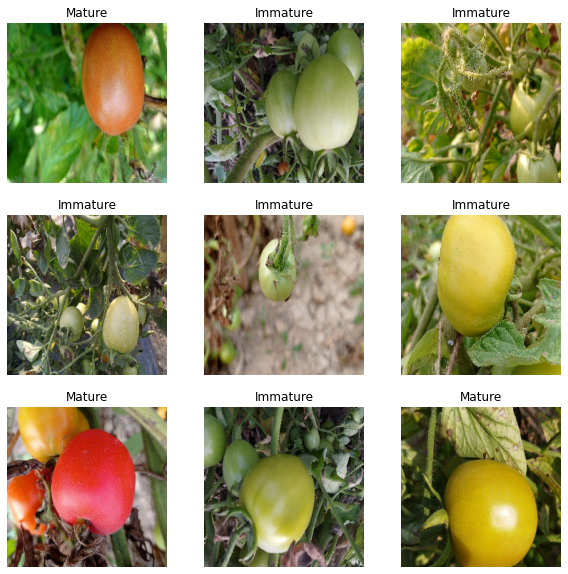

In [53]:
# Visualize a batch of images with dimensions 10x10
plt.figure(figsize=(10, 10))

# Take a batch of images from the training dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1) # subplot in a 3x3 grid. The i + 1 ensures that the subplot index starts from 1.
        plt.imshow(images[i].numpy().astype('uint8'))  #Displays the image and converts the TensorFlow to a NumPy array.
        plt.title(class_names[labels[i]]) #pixel values are in the valid range
        plt.axis("off")

plt.show()

In [52]:
#automatically tune the performance of certain operations 
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Apply caching ( avoiding redundant data loading ), shuffling(sees a variety of examples ), 
#and prefetching (allowing the data loading to be overlapped with model training) to train dataset
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Apply caching and prefetching to the validation dataset
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Models

In [9]:
# Define input shape
img_height = 224
img_width = 224
# Assuming num_classes output 4/num of class 
num_classes = 4

# CNN Model

In [10]:
# Define a simple CNN model
#first conv layer with 32 filters, each of size (3, 3), using the ReLU activation function. 
#The input_shape dimensions of the input images
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(), # output from the previous layers into a 1D array
    Dense(1024, activation='relu'), #connected layer with 1024 neurons and ReLU.
    Dropout(0.5),  # randomly setting each update during training. This helps prevent overfitting.
    Dense(units=num_classes, activation='softmax')#The output layer equal to the number of classes
])

In [11]:
# Compile the CNN model
#optimizer determines how the model weights are updated during training to minimize the loss function
#loss measures how well the model performs on the training data and guides the optimization process
#Metrics are used to evaluate the performance of the model. 
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# VGG16 Model

In [12]:
# Define VGG16 base model
vgg16_base = VGG16(
    include_top=False, #without including the top (fully connected)
    weights="imagenet", # meaning the model is initialized with weights pre-trained
    input_shape=(img_height, img_width, 3)
)

# Freeze the layers
for layer in vgg16_base.layers: #terates through all layers
    layer.trainable = False #weights will not be updated during training

# Create a new Sequential model for VGG16
model_vgg16 = Sequential([
    vgg16_base,
    GlobalAveragePooling2D(), #reducing the spatial dimensions of the feature maps.
    Dense(1024, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])


In [13]:
# Compile the VGG16 model
model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ResNet50 Model

In [14]:
# Define ResNet50 base model
resnet_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(img_height, img_width, 3)
)

# Create a new Sequential model for ResNet50
model_resnet50 = Sequential([
    resnet_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])

In [15]:
# Compile the ResNet50 model
model_resnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
# Define early stopping callback to prevent 
#monitor:overfitting metric to monitor during training  patience:number of epochs  
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train Models

In [17]:
# Train the models
#epochs the number of times the entire training dataset
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stopping])
history_vgg16 = model_vgg16.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stopping])
history_resnet50 = model_resnet50.fit(train_ds, validation_data=val_ds, epochs=5  , callbacks=[early_stopping])

Epoch 1/5
100/100 [==============================] - 652s 5s/step - loss: 33.0408 - accuracy: 0.8609 - val_loss: 0.5734 - val_accuracy: 0.8575
Epoch 2/5
100/100 [==============================] - 499s 5s/step - loss: 0.3870 - accuracy: 0.9166 - val_loss: 0.2462 - val_accuracy: 0.9375
Epoch 3/5
100/100 [==============================] - 265s 3s/step - loss: 0.2098 - accuracy: 0.9644 - val_loss: 0.1307 - val_accuracy: 0.9688
Epoch 4/5
100/100 [==============================] - 253s 3s/step - loss: 0.0693 - accuracy: 0.9778 - val_loss: 0.0832 - val_accuracy: 0.9750
Epoch 5/5
100/100 [==============================] - 253s 3s/step - loss: 0.1830 - accuracy: 0.9650 - val_loss: 0.0973 - val_accuracy: 0.9762
Epoch 1/5
100/100 [==============================] - 631s 6s/step - loss: 0.9263 - accuracy: 0.8825 - val_loss: 0.0611 - val_accuracy: 0.9800
Epoch 2/5
100/100 [==============================] - 624s 6s/step - loss: 0.0580 - accuracy: 0.9800 - val_loss: 0.0651 - val_accuracy: 0.9750
Epoch

# Evaluate the models

In [20]:
# Evaluate the models
#'evaluate' method computes the loss and metrics specified during the compilation of the model on the provided dataset.
evaluation_cnn = model_cnn.evaluate(val_ds)
evaluation_vgg16 = model_vgg16.evaluate(val_ds)
evaluation_resnet50 = model_resnet50.evaluate(val_ds)

25/25 [==============================] - 61s 2s/step - loss: 1.3466 - accuracy: 0.7763


# Compare Accuracy

In [21]:
#validation accuracy for each model, allowing you to compare their performance.
print("Validation Accuracy - CNN:", evaluation_cnn[1])
print("Validation Accuracy - VGG16:", evaluation_vgg16[1])
print("Validation Accuracy - ResNet50:", evaluation_resnet50[1])

Validation Accuracy - CNN: 0.9762499928474426
Validation Accuracy - VGG16: 0.9900000095367432
Validation Accuracy - ResNet50: 0.7762500047683716


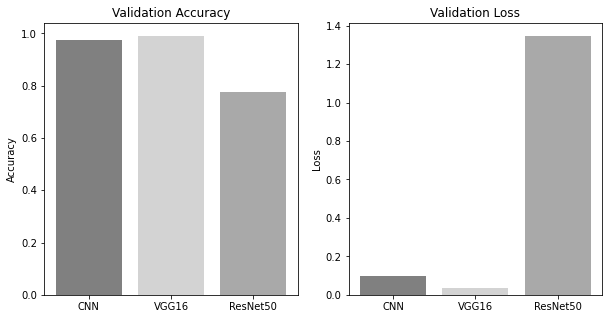

In [66]:
# Extract metrics from evaluation results
accuracy_values = [evaluation_cnn[1], evaluation_vgg16[1], evaluation_resnet50[1]]
loss_values = [evaluation_cnn[0], evaluation_vgg16[0], evaluation_resnet50[0]]

# Model names
model_names = ['CNN', 'VGG16', 'ResNet50']

# Plot accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(model_names, accuracy_values, color=['gray', 'lightgray', 'darkgray'])
plt.title('Validation Accuracy')
plt.ylabel('Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.bar(model_names, loss_values, color=['gray', 'lightgray', 'darkgray'])
plt.title('Validation Loss')
plt.ylabel('Loss')

plt.show()